# Session 6: Introduction to Neural Networks (NN's) for Regression

## Why Neural Networks?

In previous sessions we used linear and nonlinear regression. These work well when we can make a valid hypothesis on the function's form. Neural networks (NNs) remove that requirement, as they can approximate functions without making explicit asumptions on their shape.

When does this matter in practice (non-exhaustive list)?
- Problems for which the relationships between inputs and outputs is complex and /or unknown.
- Problems for which expensive iterative solvers (CFD, FEM) are needed. With enough parameters, a NN can reach an approximate solution, accurate enough.
- Cases for which  a closed-form function is not feasible (images, signals, multi-physics fields...) 

Keep in mind that Neural Networks is a general concept, and that dedicated variants exist for each class of problem (Convolutional Neural Networks for computer vision tasks, Graph Neural Networks for graph-structured data such as power systems...).

**In this exercise** we deliberately pick a simple 1D problem where we could also use nonlinear regression. This is for didactical purposes, as it allows for better visualisation and to build intuition on NN's. At the end, we will discuss why nonlinear regression could arguably be the better choice here, and when NNs truly shine.

## What is a Neural Network?

A NN is a succession of layers. Typically, it composed by linear layers alternating with activation layer. 

1. **Linear transformation** (same idea as linear regression):
$$\mathbf{z} = W\mathbf{x} + \mathbf{b}$$

2. **Activation function** (a simple nonlinearity applied element-wise):
$$\mathbf{a} = g(\mathbf{z})$$
Common choices: ReLU ($\max(0,z)$), sigmoid, tanh.

By alternating linear layers and activations, the network approximates complex nonlinear functions *using mostly linear operations*.

A Fully-Connected NN (FCNN) is one where every neuron connects to every neuron in the next layer. It has an input layer, one or more hidden layers, and an output layer.

<center><img src="https://miro.medium.com/v2/resize:fit:1400/1*LPcPbBiHSgAum3gLs15nNg.png" width="30%"/></center>

## Dataset

We approximate a noisy dataset generated from $f(x) = \sin(x) + \sin(1.5x) + \sin(2x)$:


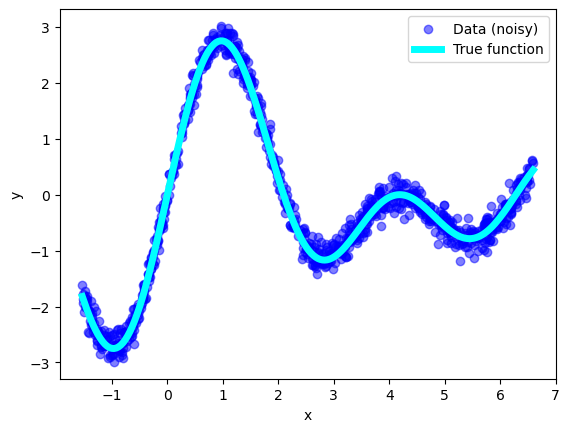

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f_true(x):
    return np.sin(x) + np.sin(1.5*x) + np.sin(2*x)

def f_noisy(x):
    return f_true(x) + 0.15 * np.random.randn(*x.shape)

n_samples = 1000
np.random.seed(42)

X = np.random.rand(n_samples, 1) * 2.6 * np.pi - np.pi / 2
Y = f_noisy(X)

x_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_plot = f_true(x_plot)

plt.scatter(X, Y, c='b', alpha=0.5, label='Data (noisy)')
plt.plot(x_plot, y_plot, c='cyan', lw=5, label='True function')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.show()


## Building the FCNN

Our function maps $\mathbb{R}^1 \to \mathbb{R}^1$, so this means that our network needs to have 1 input neuron and 1 output neuron. We also choose to set 2 hidden layers of tunable size (the width and depth of our network are tunable hyperparameters), and select the ReLU activation function for all neurons.

![Img](img/nn_architecture.png)

In PyTorch we define the network as a **class** inheriting from `nn.Module` (this is object-oriented programming: the class bundles the architecture in `__init__` and the forward pass in `forward`). We use `nn.Sequential` to stack layers. Hidden layers: `nn.Linear` + `nn.ReLU`. Output layer: `nn.Linear` only (no activation, since we want unbounded regression output). See PyTorch [Documentation](https://pytorch.org/docs/stable/nn.html#module-torch.nn.modules.module) for more details.


### Why PyTorch?
PyTorch tensors work like NumPy arrays (same syntax for matrix operations, broadcasting, etc.), but with one key addition: automatic differentiation. Every operation is recorded in a computational graph, so calling loss.backward() applies the **chain rule** and computes all gradients automatically. No need to derive or code them by hand.
In short: we write the forward pass, PyTorch gives us the gradients for free, which is a big advantage for Neural Networks.

In [ ]:
import torch
import torch.nn as nn

class MyNeuralNetwork(nn.Module): # nn.Module is used as a parent class for our custom MyNeuralNetwork class
    def __init__(self, input_size, hidden_size, output_size, num_hidden_layers):
        super().__init__() # Thanks to this line, MyNeuralNetwork inherits intialisation properties of its parent class nn.Module
        layers = []

        # Add all layers
        # We HIGHLY encourage you to try to do this exercise yourself. Pay attention to the size of the input and output of all layers. Make sure to keep the function general

        # Documentation of torch.nn.linear https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html
        # Documentation of torch.nn.ReLU  https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html

        layers.append(...)
        ... 

        self.network = nn.Sequential(*layers) 

    def forward(self, x): # This is the function that we call to get the model's prediction given an input x
        return self.network(x)

Using the class we just defined, create a neural network with 2 hidden layers and 10 neurons per hidden layer.

In [ ]:
# Fix the seed for reproducibility
torch.manual_seed(42)

input_size = ...
num_layers = ...
hidden_size = ...
output_size = ...

model = MyNeuralNetwork(...)

model  # See how it looks like

## First forward pass (before training)

Perform a forward pass on the entire data X, and see the model's output.

Note: The model's parameters were just initialised randomly, and we did not yet perform optimisation to find the optimal model parameters so **the prediction will be meaningless**. This step is for you to learn how to apply the model to a set of inputs.

In [ ]:

with torch.no_grad(): # Tells PyTorch to not calculate the gradients
    Y_first_pred = ...

plt.scatter(X, Y, c='b', alpha=0.3, label='Data')
plt.plot(x_plot, y_plot, c='cyan', lw=3, label='True function')
plt.plot(..., c='red', lw=3, label='NN prediction (untrained)')
plt.legend(); plt.xlabel('x'); plt.ylabel('y')
plt.title("Random parameters = meaningless prediction"); plt.show()

## Train / Validation / Test split and scaling

We will perform optimisation to find our model's parameters. For this purpose, we need to use a fraction of the data to train the model, and keep the rest for testing purposes. This 'test' data is not used in the optimisation process (i.e. not used in gradient computations), such that it remains a truthful indicator of the model's ability to generalise over unseen data. We propose the following split for this exercise: 

- **Train (70%)**: used for parameter updates.
- **Validation (30%)**: unbiased performance estimate.

Perform the train-test split, convert to tensors, and perform min-max scaling (question: based on what dataset should you scale?).
Scaling inputs and outputs is important for NN's, so that parameters stay in a well-behaved range and gradients are neither too large nor too small.


In [ ]:
from sklearn.model_selection import train_test_split

# Use random_state = 42 when using train_test_split
X_train, X_test, Y_train, Y_test = ...
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# Convert to tensors 

X_train_t = ...
X_test_t  = ...
Y_train_t = ...
Y_test_t  = ...

# Visualisation: 
# Try to plot the tensors using plt.scatter - does it work? Use different colors for train data and test data
plt.scatter(..., label='Train')
plt.scatter(..., label='Test')
plt.legend(); plt.xlabel('x'); plt.ylabel('y'); plt.show()

In [ ]:
# Perform min-max scaling (between -1 and 1)
def scale(...):
    return ...

X_train_s = ...
X_test_s = ...
Y_train_s = ...
Y_test_s = ...

## Loss function and optimiser

The loss measures how far predictions are from true values (called *labels*). We propose to use MSE in this exercise (see previous exercise sessions):

$$J(\boldsymbol{\theta}) = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

where $\boldsymbol{\theta}$ denotes **all model parameters** (weights $W$ *and* biases $\mathbf{b}$ of every layer). Training solves:

$$\boldsymbol{\theta}^* = \arg\min_{\boldsymbol{\theta}} \; J(\boldsymbol{\theta})$$

Same idea as nonlinear regression, but now with hundreds of parameters instead of a handful. The loss surface is non-convex, so we use gradient-based optimisers (here: Adam).


In [ ]:
import torch.optim as optim

criterion = ... # Find how to create a MSE object with torch.nn
optimiser = optim.Adam(model.parameters(), lr = 1e-3) # What is 'lr' ?

print("Model parameters (weights AND biases):")
total = 0
for name, param in model.named_parameters():
    print(f"  {name:30s} {str(list(param.shape)):15s}  ({param.numel()} params)")
    total += param.numel()
print(f"\nTotal trainable parameters: {total}")

# QUESTION: do you see parameters for every layer? Is it as expected?

## Backpropagation

Since this is an optimisation problem in which we are looking for optimal parameters, we need to compute the gradient of $J$ with respect to *every* parameter (see previous exercise session on nonlinear regression).

$$\nabla_{\boldsymbol{\theta}} J = \left(\frac{\partial J}{\partial w_1}, \frac{\partial J}{\partial b_1}, \frac{\partial J}{\partial w_2}, \ldots\right)$$

Backpropagation computes this gradient efficiently via the **chain rule** (see calculus theory). For instance, to get $\frac{\partial J}{\partial W_1}$ in a two-layer network:

$$\frac{\partial J}{\partial W_1} = \frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial \mathbf{a}_2} \cdot \frac{\partial \mathbf{a}_2}{\partial \mathbf{z}_2} \cdot \frac{\partial \mathbf{z}_2}{\partial \mathbf{a}_1} \cdot \frac{\partial \mathbf{a}_1}{\partial \mathbf{z}_1} \cdot \frac{\partial \mathbf{z}_1}{\partial W_1}$$

Each factor is simple: loss derivative, activation derivative (0 or 1 for ReLU), weight matrix, input vector... Everything is relatively cheap to compute as the layers are linear transformations + simple activations. This is where PyTorch shines, as it builds a computation graph during the forward pass and applies the chain rule automatically with `loss.backward()`.

Once the gradient has been obtained with backpropagation, every parameter can be updated using gradient descent:

$$\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_{k} - \alpha \, \nabla_{\boldsymbol{\theta}} J$$

## One optimisation step (manually)

We will now go through one iteration manually. This is purely for didactic purposes, in practice this is done with a loop. The loss, i.e. our objective function to minimise, is computed by comparing each model's output with the labels (expected result). The gradient of the loss is computed, which informs how to update each parameter to get closer to the objective.


In [ ]:
output = model(X_train_s)
loss = criterion(output, Y_train_s) # Compute the total loss. This compares all model predictions in the train data to the labels, and computes MSE

optimiser.zero_grad()   # Clear old gradients
loss.backward()         # Backpropagation: compute all gradients
optimiser.step()        # Update all parameters (weights + biases)

# Check: did the loss decrease?
output2 = ...
loss2   = ...

print(f"Loss before: {loss.item():.4f}")
print(f"Loss after:  {loss2.item():.4f}")

## Training loop

Repeat forward-backward-update for many epochs (epoch = complete pass through the entire training dataset). We iteratively get a better model through this optimisation process. We also monitor test loss at each epoch, but we do **not** use it for updates. This gives us useful indications about overfitting.


In [ ]:
train_loss_list = []
test_loss_list = []

num_epochs = 5000
for epoch in range(num_epochs):
    # Forward pass
    output = ...

    # Training loss
    loss = ...

    # Test loss (no gradient needed)
    with torch.no_grad():
         output_test = ...
         loss_test   = ...

    # Backprop + Update
    ...
    ...
    ...

    train_loss_list.append(loss.item())
    test_loss_list.append(loss_test.item())
    if (epoch + 1) % 500 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train: {loss.item():.4f}, Val: {loss_test.item():.4f}')

plt.plot(train_loss_list, label='Train'); plt.plot(test_loss_list, label='Test')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.yscale('log'); plt.legend(); plt.show()


## Evaluation

Evaluate the model's performances on the test dataset

In [ ]:
def unscale(data_s, dmin, dmax):
    return ...

# Visualisation only (for didactical purpose)
with torch.no_grad():
    X_plot_t = ...
    X_plot_s = ...
    
    Y_pred_s = ...
    Y_pred = ...

plt.scatter(X_test, Y_test, c='g', alpha=0.5, s=10, label='Test data (unseen)')
plt.plot(x_plot, y_plot, c='cyan', lw=3, label='True function')
plt.plot(x_plot, Y_pred.numpy(), c='red', lw=3, label='NN (trained)')
plt.plot(x_plot, Y_first_pred.numpy(), c='orange', lw=3, ls='--', label='NN (before training)')
plt.legend(); plt.xlabel('x'); plt.ylabel('y')
plt.title("Trained NN prediction vs. unseen test data"); plt.show()

# Unbiased comparison
with torch.no_grad():
    X_test_s = ...

    Y_pred_s = ...
    Y_pred = ...

    test_loss = criterion(model(X_test_s), Y_test_s)
    print(f"Test loss (MSE, scaled): {test_loss.item():.4f}")

plt.scatter(Y_test, Y_pred, c='k', alpha=0.5, s=10)
# Red diagonal dashed
plt.plot(Y_test, Y_test, c='red', lw=2, ls='--', alpha=0.7)
plt.xlabel('Actual'), plt.ylabel('Predicted')
plt.title("Parity Plot: Testing set")
plt.show()

## Key takeaway

Our model is a stack of **linear transformations** ($W\mathbf{x}+\mathbf{b}$) with simple **ReLU activations** ($\max(0,z)$). Most of the computation is linear, yet the network approximates a complex nonlinear function.

This is what makes NNs scalable: the math is simple (linear algebra + pointwise activations), and the modern hardware handles it efficiently. Backpropagation is fast for the same reason: derivatives through linear layers and ReLU are trivial to compute.


## Bonus: L1 regularisation

Same idea as **Lasso regression**: add $\lambda \sum_k |\theta_k|$ to the loss to penalise large parameters and encourage sparsity. Here we apply it to *all* model parameters.

$$J_{\text{reg}}(\boldsymbol{\theta}) = J(\boldsymbol{\theta}) + \lambda \sum_{k} |\theta_k|$$

Below: full pipeline for you to experiment with one cell. Try to change the model hyperparameters and observe the results.

In [ ]:
# Recap with L1 regularization
n_samples = 1000; np.random.seed(42)

X2 = np.random.rand(n_samples, 1) * 2.6 * np.pi - np.pi / 2
Y2 = f_true(X2) + 0.15 * np.random.randn(*X2.shape)

X2_tr, X2_te, Y2_tr, Y2_te = train_test_split(X2, Y2, test_size=0.30, random_state=42)

X2_tr_t = torch.tensor(X2_tr, dtype=torch.float32)
X2_te_t = torch.tensor(X2_te, dtype=torch.float32)
Y2_tr_t = torch.tensor(Y2_tr, dtype=torch.float32)
Y2_te_t = torch.tensor(Y2_te, dtype=torch.float32)

Xm, XM = X2_tr_t.min(), X2_tr_t.max()
Ym, YM = Y2_tr_t.min(), Y2_tr_t.max()

X2_tr_s = scale(X2_tr_t, Xm, XM); X2_te_s = scale(X2_te_t, Xm, XM)
Y2_tr_s = scale(Y2_tr_t, Ym, YM); Y2_te_s = scale(Y2_te_t, Ym, YM)

torch.manual_seed(42)

model2 = MyNeuralNetwork(1, 10, 1, 3)
criterion2 = nn.MSELoss()
optimizer2 = optim.Adam(model2.parameters(), lr=1e-3)

lambda_reg = 0.00008 # Regularisation

train_loss2, test_loss2 = [], []
for epoch in range(7000):

    out = model2(X2_tr_s)
    loss = criterion2(out, Y2_tr_s)
    l1 = sum(torch.norm(p, 1) for p in model2.parameters())
    loss_total = loss + lambda_reg * l1

    with torch.no_grad():
        loss_te = criterion2(model2(X2_te_s), Y2_te_s) + lambda_reg * l1

    optimizer2.zero_grad(); loss_total.backward(); optimizer2.step()
    train_loss2.append(loss_total.item()); test_loss2.append(loss_te.item())

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/7000], Train: {loss_total.item():.4f}, Test: {loss_te.item():.4f}')

plt.plot(train_loss2, label='Train'); plt.plot(test_loss2, label='Test')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.yscale('log'); plt.legend(); plt.show()

with torch.no_grad():
    Y2_pred = unscale(model(X2_te_s), Ym, YM)
    
plt.scatter(X2_te, Y2_te, c='g', alpha=0.4, s=10, label='Test')
plt.plot(x_plot, y_plot, c='cyan', lw=1.5, label='True')
plt.scatter(X2_te, Y2_pred, c='red', alpha=0.4, s=10, label='NN + L1')
plt.legend(); plt.xlabel('x'); plt.ylabel('y'); plt.title('With L1 regularization'); plt.show()

## Closing remarks

**For this problem, nonlinear regression would be better**: we have a single input/output (in this case easy to visualise and guess the form), synthetic well-behaved data, and ~ 6 parameters would suffice vs. hundreds here (i.e. we could get a more lightweight model). The exercise is left (and encouraged) to the reader.

**NNs become the right tool when** (nonexhaustive list): the input space is high-dimensional, the relationship is unknown or too complex for an analytical model, we need a fast surrogate for an expensive solver, or interactions and nonlinearities defeat simplified models.

In the next exercise we tackle handwritten digit classification, where the input is an image and classical regression simply cannot compete.

### Real-world application: LES of Combustion

![Img](img/nn_dns.png)
![Img](img/nn_dns_res.png)

## Additional resources

* A really good series of videos from [3Blue1Brown](https://www.youtube.com/watch?v=aircAruvnKk&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi)
* Pytorch [documentation](https://pytorch.org/docs/stable/index.html) and [tutorials](https://pytorch.org/tutorials/beginner/basics/intro.html)
* Neural Network intuition: https://playground.tensorflow.org